In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Load Dataset


In [2]:
df = pd.read_csv("/content/drive/MyDrive/ML Projects/Student Social Media And Mental Health Impact.csv")
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


Check Missing Values

In [3]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


Check Duplicate Values

In [4]:
df.duplicated().sum()

np.int64(2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

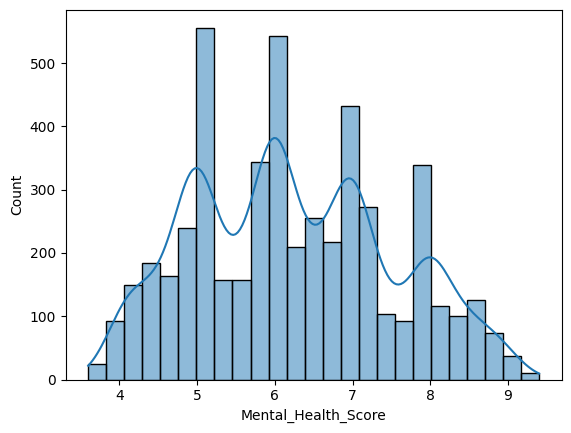

In [7]:
sns.histplot(df["Mental_Health_Score"],kde=True)

<Axes: >

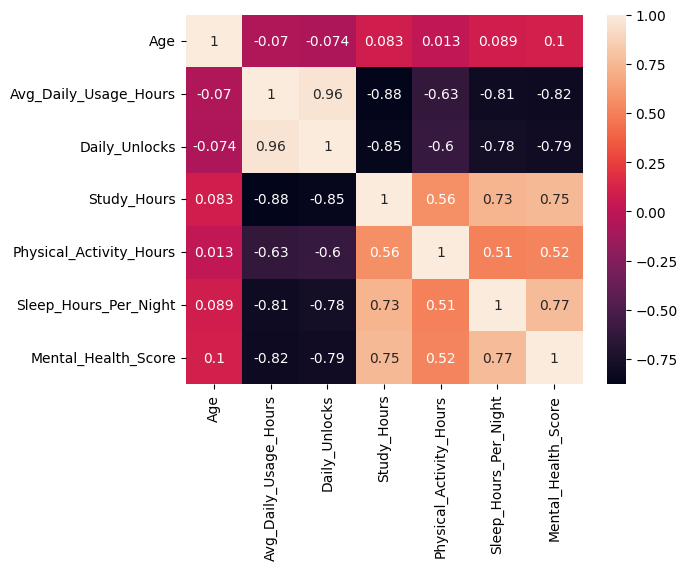

In [8]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [9]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

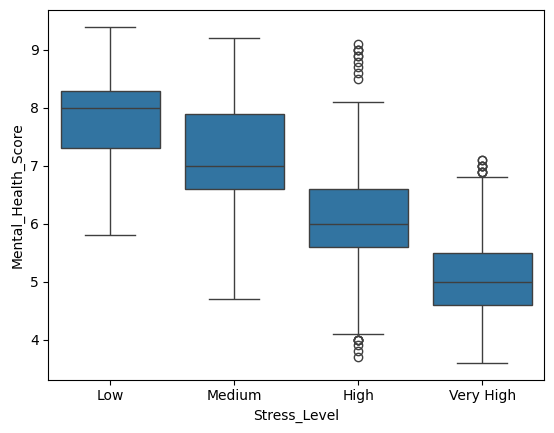

In [10]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score',data=df, order=order)

Most Used Platform (count)

In [11]:
df['Most_Used_Platform'].value_counts()

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


<Axes: xlabel='Most_Used_Platform', ylabel='count'>

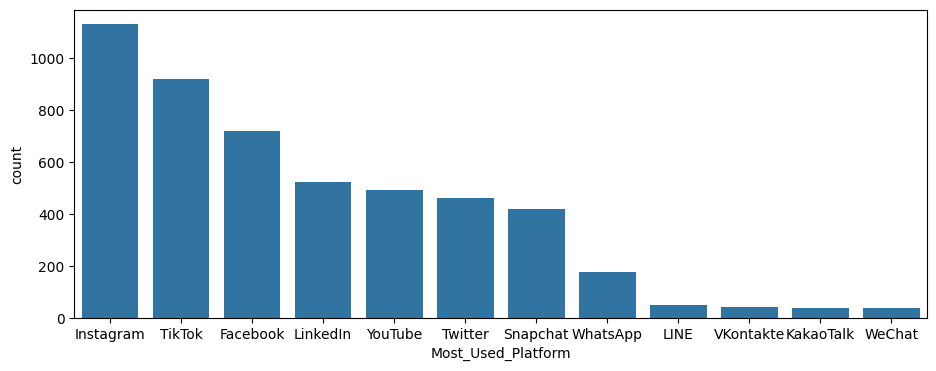

In [12]:
plt.figure(figsize=(11, 4))
sns.countplot(x=df['Most_Used_Platform'], order=df['Most_Used_Platform'].value_counts().index)

Checking Outlires

In [13]:
num_features = df.select_dtypes(include='number') #int64 or float64
Q1  = num_features.quantile(0.25)
Q3  = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


Data Cleaning & Preprocessing

## 1. Handling Duplicates Values

In [14]:
#Since there are only 2 duplicate values we delete the value from the dataset
df.drop_duplicates(inplace=True)

In [15]:
# Correcting impossible negative 'Physical_Activity_Hours' values
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].apply(lambda x: max(x, 0))

# Verify the minimum value is now non-negative
print(f"Minimum Physical_Activity_Hours after correction: {df['Physical_Activity_Hours'].min()}")

Minimum Physical_Activity_Hours after correction: 0.0


## 2. Skewness

**What skewness is**: a measure of how lopsided a numeric column's distribution is. A value near 0 means roughly symmetric (bell-shaped); a large positive or negative value means the data leans heavily to one side, with a long tail.

**Why it matters**: models like Linear Regression assume features are roughly well-behaved. A heavily skewed column (think: a long tail of extreme values) can quietly drag the model's predictions in that direction. Tree-based models like Random Forest don't care about skew — but since we're also training a Linear Regression baseline, it's worth fixing.

In [16]:
num_colms = df.select_dtypes(include="number").skew()
num_colms

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


# Feature Engineering

One meaningful engineered feature here: grouping **Country.**

Country has 111 unique values in this dataset — one-hot encoding that directly would add 110+ mostly-empty columns, which hurts the model far more than it helps (this is called high cardinality).
Dropping Country entirely throws away real signal — a student's country genuinely correlates with things like internet access, culture, and sleep norms.
The fix: keep the top 10 most frequent countries as their own category, and bucket everything else into "Other". We keep the signal that matters and lose the noise that doesn't.

In [17]:
df['Country'].unique()
#Country has 111 unique values

array(['Other', 'Canada', 'USA', 'India', 'Australia', 'UK', 'Germany',
       'Bangladesh', 'Brazil', 'Japan', 'South Korea', 'France', 'Spain',
       'Italy', 'Mexico', 'Russia', 'China', 'Sweden', 'Norway',
       'Denmark', 'Netherlands', 'Belgium', 'Switzerland', 'Austria',
       'Portugal', 'Greece', 'Ireland', 'New Zealand', 'Singapore',
       'Malaysia', 'Thailand', 'Vietnam', 'Philippines', 'Indonesia',
       'Taiwan', 'Hong Kong', 'Turkey', 'Israel', 'UAE', 'Egypt',
       'Morocco', 'South Africa', 'Nigeria', 'Kenya', 'Ghana',
       'Argentina', 'Chile', 'Colombia', 'Peru', 'Venezuela', 'Ecuador',
       'Uruguay', 'Paraguay', 'Bolivia', 'Costa Rica', 'Panama',
       'Jamaica', 'Trinidad', 'Bahamas', 'Iceland', 'Finland', 'Poland',
       'Romania', 'Hungary', 'Czech Republic', 'Slovakia', 'Croatia',
       'Serbia', 'Slovenia', 'Bulgaria', 'Estonia', 'Latvia', 'Lithuania',
       'Ukraine', 'Moldova', 'Belarus', 'Kazakhstan', 'Uzbekistan',
       'Kyrgyzstan', 'Tajiki

In [18]:
top_countries = df['Country'].value_counts().index[:10].tolist()
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'
df['Group_Country'] = df['Country'].apply(group_countries)
df['Group_Country'].value_counts()

,count
Group_Country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [19]:
df.head(3)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Group_Country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada


# Encoding Strategy
1. Stress_Level column have only 4 values low< medium< high< very High
  so Stress Level → Ordinal Encoding

2. The columns which are having string or object values
  [ Gender, Academic_Level, Most_Used_Platform, Purpose_Of_Use, Country_Grouped ]
  we perform One-hot-Encoding

# train test spilt

In [20]:
from sklearn.model_selection import train_test_split


X = df.drop(columns=['Mental_Health_Score', 'Country'])
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Preprocessing using Columntransformer
* Study_Hours (the skewed one) → impute → log1p transform → scale
* The other numeric columns → impute → scale (no skew to fix)
* The nominal columns → impute → OneHotEncoder

In [21]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Define column categories for preprocessing
skewed_cols = ['Study_Hours']
ordinal_cols = ['Stress_Level']

# Identify nominal (categorical) columns. 'Country' is replaced by 'Group_Country'.
nominal_cols = ['Gender', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Group_Country']

# Identify other numeric columns (all numeric except 'Study_Hours' and the target 'Mental_Health_Score')
numeric_features_in_df = df.select_dtypes(include=np.number).columns.tolist()
other_numeric_cols = [col for col in numeric_features_in_df if col not in skewed_cols + ['Mental_Health_Score']]

# 1. Skewed features pipeline: apply log1p transformation then scale
skew_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p, validate=False)),
    ('scale', StandardScaler())
])

# 2. Plain Numeric Features pipeline: just scale
plain_numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# 3. Ordinal features pipeline: encode Stress_Level with a defined order
ordinal_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']], handle_unknown='error'))
])

# 4. Nominal Features pipeline: One-Hot Encode other categorical features
nominal_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown="ignore"))
])

# Combine all pipelines into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("Skewed_Features", skew_pipeline, skewed_cols),
        ("Plain_Numeric_Features", plain_numeric_pipeline, other_numeric_cols),
        ('Ordinal_Features', ordinal_pipeline, ordinal_cols),
        ('Nominal_Features', nominal_pipeline, nominal_cols)
    ],
    remainder='passthrough'
)


In [22]:
# Apply the ColumnTransformer to the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape of processed X_train:", X_train_processed.shape)
print("Shape of processed X_test:", X_test_processed.shape)


Shape of processed X_train: (3498, 38)
Shape of processed X_test: (1500, 38)


# Build Pipelines
We'll build two pipelines below — one per model — so we can fairly compare them.

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Model Building

Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

In [25]:
lr_r2_testing  = r2_score(y_test, y_pred_lr)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae         = mean_absolute_error(y_test, y_pred_lr)
lr_mse         = mean_squared_error(y_test, y_pred_lr)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')
print(f'MSE {lr_mse}')

Accuracy of Training 0.7236771199387538
Accuracy of Testing 0.739794461743302
MAE 0.5361775634720183
MSE 0.45701905273488


Random Forest (default settings)

In [26]:

from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds          = rf_pipeline.predict(X_test)
rf_preds_training = rf_pipeline.predict(X_train)

rf_r2_testing  = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_training)
rf_mae         = mean_absolute_error(y_test, rf_preds)
rf_mse         = mean_squared_error(y_test, rf_preds)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print(f"MAE : {rf_mae}")
print(f"MSE : {rf_mse}")

Accuracy of Training 0.9808287942404612
Accuracy of Testing 0.8775888638668996
MAE : 0.34722113333333343
MSE : 0.21500011819333337


Hyperparameter Tuning the Random Forest

In [27]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random forest__n_estimators': [200, 300, 500, 700, 1000],
    'random forest__max_depth': [None, 10, 15, 20, 25, 30, 40],
    'random forest__min_samples_split': [2, 5, 10, 15, 20],
    'random forest__min_samples_leaf': [1, 2, 4, 6, 8],
    'random forest__max_features': ['sqrt', 'log2', None, 0.5, 0.8]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('Skewed_Features',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Plain_Numeric_Features',
                                                                               Pipeline(steps=[('...
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'random forest__max_depth': [None, 10,
                                                                     15, 20, 25,
                                                                     30, 40],
                                        'random forest__max_features': ['sqrt',
                                                                        'log2',
                                                                        None,
                                                                        0.5,
                                                                        0.8],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4,
                                                                            6,
                                                                            8],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10,
                                                                             15,
                                                                             20],
                                        'random forest__n_estimators': [200,
                                                                        300,
                                                                        500,
                                                                        700,
                                                                        1000]},
                   random_state=42, scoring='r2')

In [28]:
random_search.best_params_

{'random forest__n_estimators': 1000,
 'random forest__min_samples_split': 2,
 'random forest__min_samples_leaf': 1,
 'random forest__max_features': 0.5,
 'random forest__max_depth': 30}

In [29]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds    = rf_best_pipeline.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.8861840115103266
MAE Score for random forest after hyperparameter tuning 0.33605884281544757


Model Evaluation

In [30]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)


                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.739794     0.723677  0.536178  0.676032
1  Random Forest (default)  0.877589     0.980829  0.347221  0.463681
2    Random Forest (tuned)  0.886184     0.982891  0.336059  0.447106


# Save the Model
We save the entire pipeline — preprocessing and model together — as a single file, not just the raw model.

In [31]:
import joblib
joblib.dump(rf_pipeline, 'Mental_Health_score_Preidiction_Model.pkl')

['Mental_Health_score_Preidiction_Model.pkl']